# Japan cherry — *Cerasus yedoensis* vs *Cerasus sargentii*

Exploratory data analysis of two GMU-Japan subsets, side-by-side:

| Key | Species | Common name |
|---|---|---|
| `GMU_Cherry_Japan_Y` | *Cerasus yedoensis* | Somei-yoshino |
| `GMU_Cherry_Japan_S` | *Cerasus sargentii* | Sargent's cherry |

Both target the GMU peak-bloom day-of-year code `gmu_0`. This notebook uses the
`pysephone.visualize.dataset` plotting suite — every figure is produced by a
single library call so the same recipe transfers to any other `Observations`
instance.

Sections:

1. Config + load
2. Basic summary statistics (counts, year range, locations)
3. Spatial coverage maps
4. Bloom-DOY distributions (histograms)
5. Bloom DOY over time (scatter)
6. Annual-mean trend with linear fit
7. Per-location temporal coverage
8. Direct yedoensis-vs-sargentii comparison plots

## 1. Config + imports

In [1]:
from __future__ import annotations

from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pysephone.constants import KEY_OBSERVATIONS, KEY_OBS_TYPE, KEY_YEAR
from pysephone.dataset.dataset import Dataset
from pysephone.visualize.dataset import (
    observation_doy_histograms,
    observation_doy_over_time,
    observation_mean_trend,
    observation_map,
    species_subgroup_timeline,
)

# The target observation type both datasets share.
TARGET = 'gmu_0'

# (registry key, friendly label) — order is preserved in every comparison plot.
DATASETS = [
    ('GMU_Cherry_Japan_Y', 'yedoensis'),
    ('GMU_Cherry_Japan_S', 'sargentii'),
]

# Colour map used throughout for side-by-side comparisons.
COLORS = {
    'yedoensis': '#e07a5f',  # warm pink
    'sargentii': '#3d5a80',  # deep blue
}

print('Datasets:', [n for n, _ in DATASETS])
print('Target:  ', TARGET)

Datasets: ['GMU_Cherry_Japan_Y', 'GMU_Cherry_Japan_S']
Target:   gmu_0


## 2. Load both datasets

No feature providers are attached — this notebook is observations-only, so it
needs nothing from disk beyond the GMU bloom records (no AgERA5 / OpenMeteo
download required).

In [2]:
datasets: dict[str, Dataset] = {}
for ds_key, label in DATASETS:
    ds = Dataset.load(ds_key)
    datasets[label] = ds
    print(f'  {label:10s}  ({ds_key}):  {len(ds):5d} samples,  '
          f'{len(set(ds.years)):3d} years,  '
          f'{len(ds.locations):4d} locations')

  yedoensis   (GMU_Cherry_Japan_Y):   1997 samples,   36 years,    67 locations
  sargentii   (GMU_Cherry_Japan_S):    225 samples,   36 years,     8 locations


## 3. Summary statistics

A compact table summarising the two subsets. Bloom DOY is extracted from each
sample's `gmu_0` observation; everything else is read straight off the
`Dataset` / `Observations` properties.

In [3]:
def doy_series(ds: Dataset, obs_type: str) -> pd.Series:
    """Pull a flat Series of bloom DOYs for ``obs_type`` out of a Dataset."""
    df = ds.observations.df_y.xs(obs_type, level=KEY_OBS_TYPE)[KEY_OBSERVATIONS]
    return df.apply(lambda d: d.dayofyear if hasattr(d, 'dayofyear') else int(d))


doy = {label: doy_series(ds, TARGET) for label, ds in datasets.items()}

summary = pd.DataFrame({
    label: {
        'n samples':   len(ds),
        'n locations': len(ds.locations),
        'n years':     len(set(ds.years)),
        'year min':    min(ds.years),
        'year max':    max(ds.years),
        'DOY mean':    round(float(doy[label].mean()), 2),
        'DOY std':     round(float(doy[label].std()), 2),
        'DOY min':     int(doy[label].min()),
        'DOY max':     int(doy[label].max()),
    }
    for label, ds in datasets.items()
})
summary

,yedoensis,sargentii
n samples,1997.00,225.00
n locations,67.00,8.00
n years,36.00,36.00
year min,1986.00,1986.00
year max,2021.00,2021.00
DOY mean,98.96,130.48
DOY std,9.71,6.88
DOY min,80.00,115.00
DOY max,137.00,148.00


## 4. Spatial coverage

Where in Japan each species was recorded. Uses
`pysephone.visualize.dataset.observation_map`, which draws bundled
Natural-Earth admin boundaries underneath the observation points.

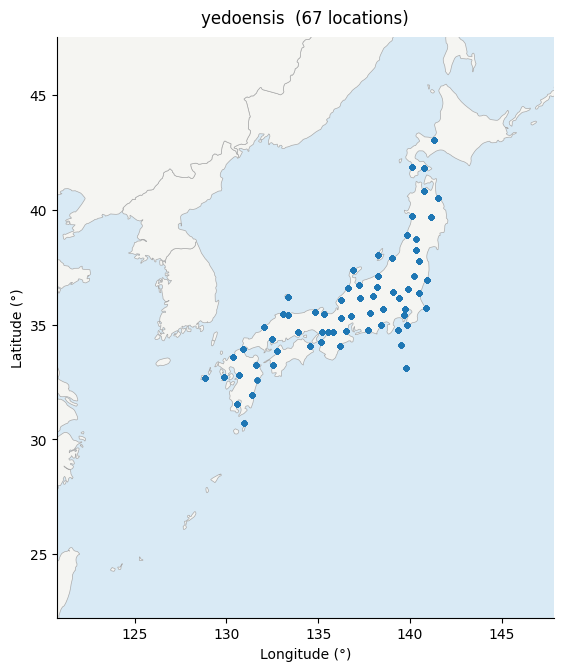

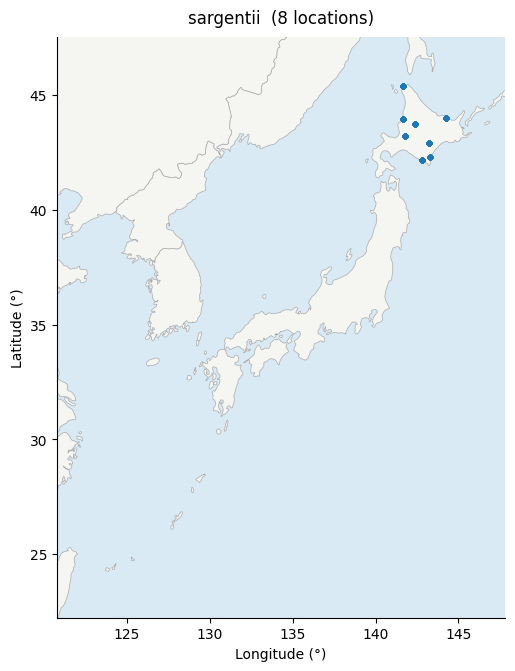

In [4]:
for label, ds in datasets.items():
    fig = observation_map(ds.observations, point_size=10, alpha=0.7)
    fig.suptitle(f'{label}  ({len(ds.locations)} locations)', y=1.02, fontsize=12)
    plt.show()

## 5. Bloom-DOY distribution per dataset

Histogram of the `gmu_0` day-of-year values. Dashed line = mean DOY for that
dataset.

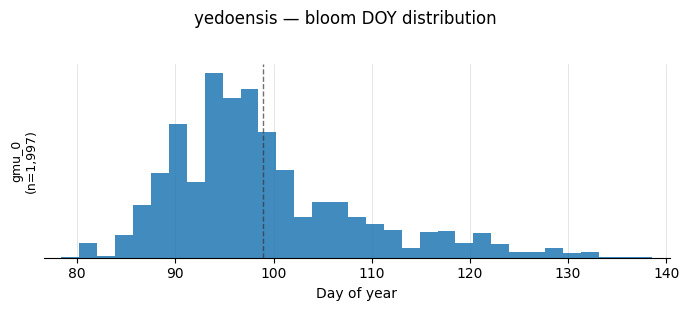

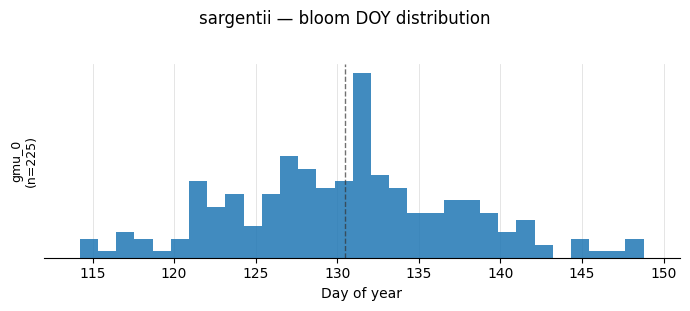

In [5]:
for label, ds in datasets.items():
    fig = observation_doy_histograms(ds.observations, n_bins=35)
    fig.suptitle(f'{label} — bloom DOY distribution', y=1.02, fontsize=12)
    plt.show()

## 6. Bloom DOY over time

One scatter per dataset, with a dashed line at the long-term mean. Useful for
spotting (a) data coverage gaps in time and (b) any obvious year-to-year
swings.

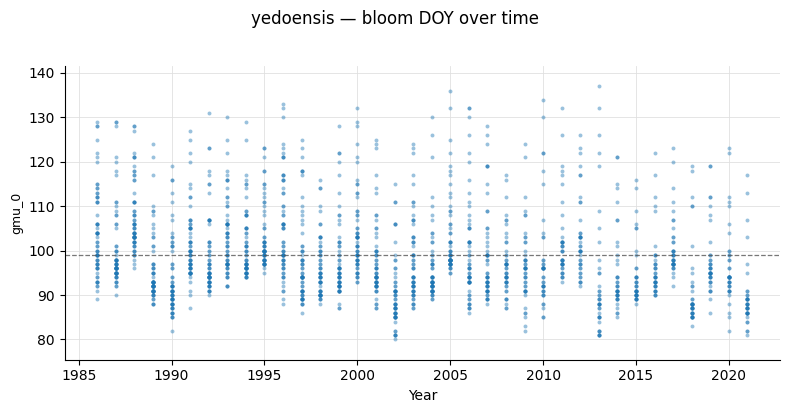

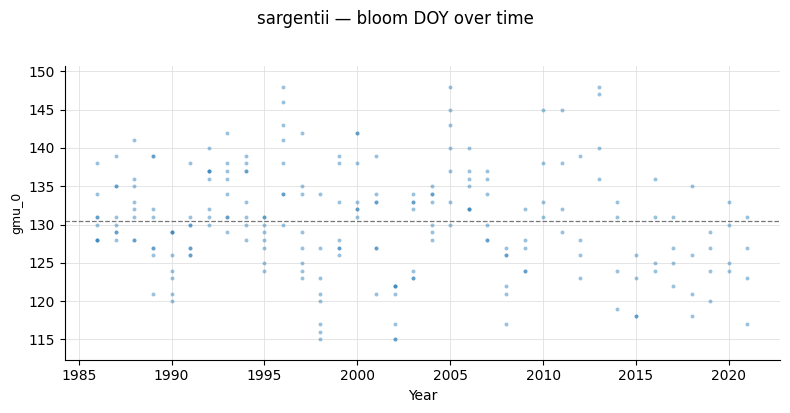

In [6]:
for label, ds in datasets.items():
    fig = observation_doy_over_time(ds.observations, point_size=8, alpha=0.45)
    fig.suptitle(f'{label} — bloom DOY over time', y=1.02, fontsize=12)
    plt.show()

## 7. Annual-mean trend with linear fit

`observation_mean_trend` collapses each year to its mean DOY and fits a linear
trend. The slope (days per year) is shown in the legend — a strongly negative
slope indicates earlier blooms over the period.

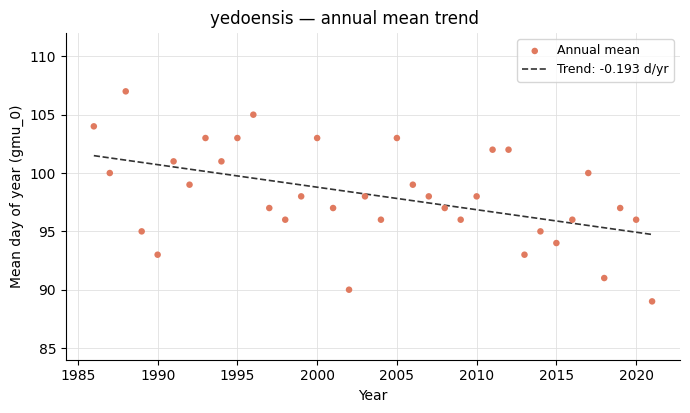

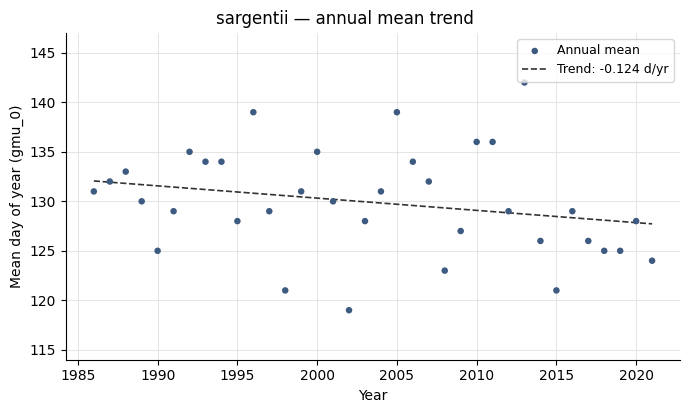

In [7]:
for label, ds in datasets.items():
    fig = observation_mean_trend(ds.observations, obs_type=TARGET, color=COLORS[label])
    fig.suptitle(f'{label} — annual mean trend', y=1.02, fontsize=12)
    plt.show()

## 8. Per-location temporal coverage

Broken-bar chart of which years each `(source, species, subgroup)` was
recorded. With aggregate-in-grid enabled by the registry, "species" here are
the spatial bins rather than individual stations.

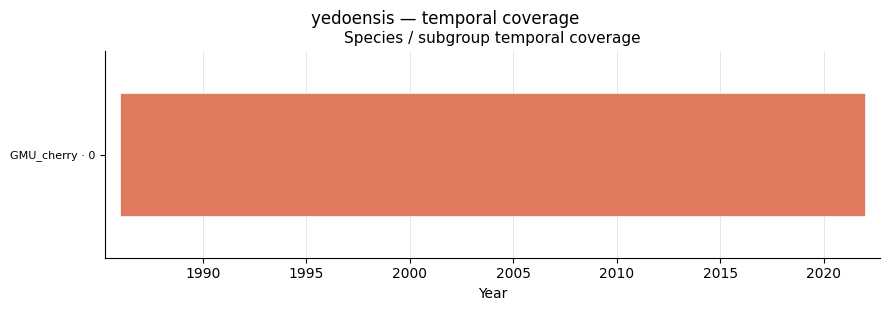

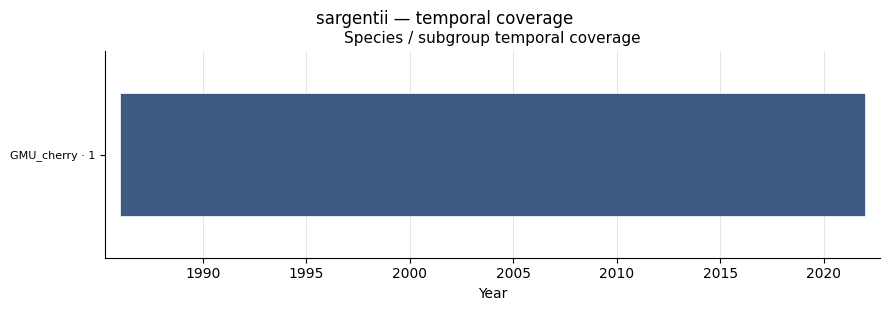

In [8]:
for label, ds in datasets.items():
    fig = species_subgroup_timeline(ds.observations, color=COLORS[label])
    fig.suptitle(f'{label} — temporal coverage', y=1.02, fontsize=12)
    plt.show()

## 9. Direct yedoensis-vs-sargentii comparison

The library plots above show each dataset on its own. The cells below overlay
the two species directly so differences in central tendency, spread, and trend
are visible at a glance.

### 9a. Overlaid DOY histograms

Both densities plotted on a single axis with shared bins. Mean DOY per
dataset is marked with a dashed vertical line.

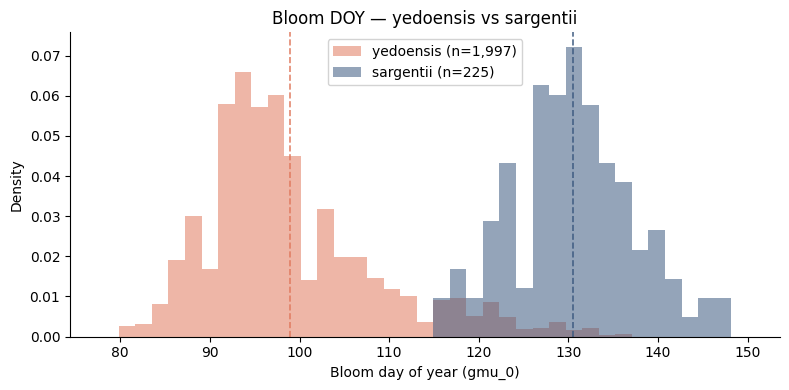

In [9]:
all_doys = np.concatenate([s.values for s in doy.values()])
bins = np.linspace(all_doys.min() - 2, all_doys.max() + 2, 40)

fig, ax = plt.subplots(figsize=(8, 4))
for label, series in doy.items():
    ax.hist(series.values, bins=bins, density=True,
            alpha=0.55, color=COLORS[label],
            label=f'{label} (n={len(series):,})', edgecolor='none')
    ax.axvline(series.mean(), color=COLORS[label], linestyle='--',
               linewidth=1.2, alpha=0.9)
ax.set_xlabel('Bloom day of year (gmu_0)')
ax.set_ylabel('Density')
ax.set_title('Bloom DOY — yedoensis vs sargentii')
ax.legend(framealpha=0.85)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 9b. Annual-mean trend, overlaid

Each year is collapsed to its mean DOY for that species; the trends are then
plotted on a single axis with their linear fits. The legend reports the slope
(d/yr) so the two warming responses can be compared directly.

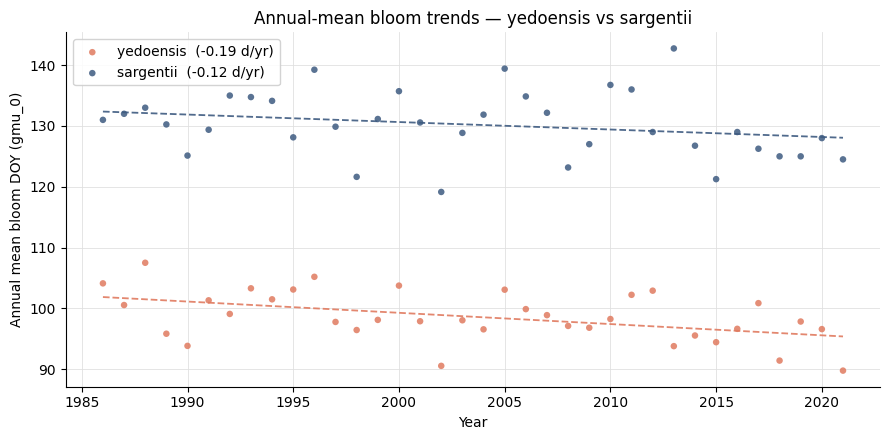

In [10]:
def annual_mean(ds: Dataset, obs_type: str) -> pd.Series:
    df = ds.observations.df_y.xs(obs_type, level=KEY_OBS_TYPE)[KEY_OBSERVATIONS]
    df = df.apply(lambda d: d.dayofyear if hasattr(d, 'dayofyear') else int(d))
    return df.groupby(level=KEY_YEAR).mean()


fig, ax = plt.subplots(figsize=(9, 4.5))
for label, ds in datasets.items():
    means = annual_mean(ds, TARGET)
    xs = means.index.values.astype(float)
    ys = means.values
    slope, intercept = np.polyfit(xs, ys, 1)
    xs_line = np.linspace(xs.min(), xs.max(), 200)
    ax.scatter(xs, ys, color=COLORS[label], s=22, alpha=0.85,
               label=f'{label}  ({slope:+.2f} d/yr)', edgecolors='none')
    ax.plot(xs_line, np.polyval([slope, intercept], xs_line),
            '--', color=COLORS[label], linewidth=1.3, alpha=0.9)

ax.set_xlabel('Year')
ax.set_ylabel(f'Annual mean bloom DOY ({TARGET})')
ax.set_title('Annual-mean bloom trends — yedoensis vs sargentii')
ax.legend(framealpha=0.85)
ax.grid(color='#e0e0e0', linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 9c. Bloom DOY vs latitude

Both species on one panel. A latitudinal gradient — bloom getting later
the further north you go — should show up as a positive slope. Differences
in slope and offset hint at species-specific climate sensitivity.

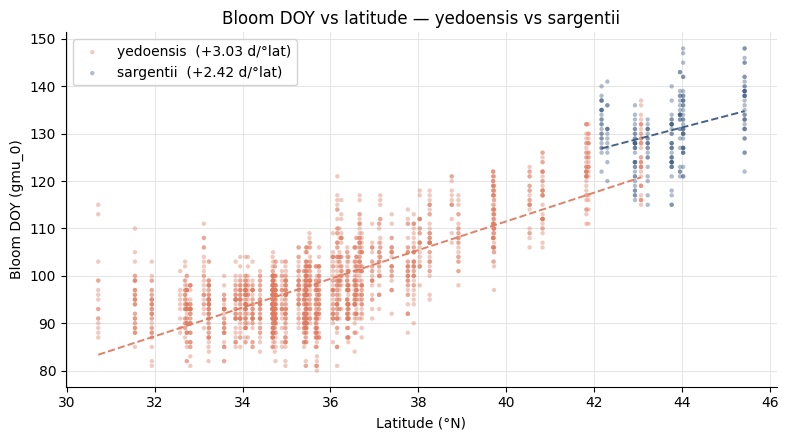

In [11]:
def doy_vs_latitude(ds: Dataset, obs_type: str) -> pd.DataFrame:
    """Return one row per sample with columns (lat, doy)."""
    rows = []
    for item in ds.iter_items():
        bloom = item[KEY_OBSERVATIONS].get(obs_type)
        if bloom is None:
            continue
        d = bloom.dayofyear if hasattr(bloom, 'dayofyear') else int(bloom)
        rows.append((item['lat'], d))
    return pd.DataFrame(rows, columns=['lat', 'doy'])


fig, ax = plt.subplots(figsize=(8, 4.5))
for label, ds in datasets.items():
    df = doy_vs_latitude(ds, TARGET)
    slope, intercept = np.polyfit(df['lat'].values, df['doy'].values, 1)
    xs_line = np.linspace(df['lat'].min(), df['lat'].max(), 100)
    ax.scatter(df['lat'], df['doy'], color=COLORS[label], s=10, alpha=0.4,
               edgecolors='none',
               label=f'{label}  ({slope:+.2f} d/°lat)')
    ax.plot(xs_line, np.polyval([slope, intercept], xs_line),
            '--', color=COLORS[label], linewidth=1.4, alpha=0.95)

ax.set_xlabel('Latitude (°N)')
ax.set_ylabel(f'Bloom DOY ({TARGET})')
ax.set_title('Bloom DOY vs latitude — yedoensis vs sargentii')
ax.legend(framealpha=0.85)
ax.grid(color='#e0e0e0', linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 9d. Combined map

Both species on one panel with country boundaries. Useful for seeing how the
yedoensis and sargentii station networks overlap geographically.

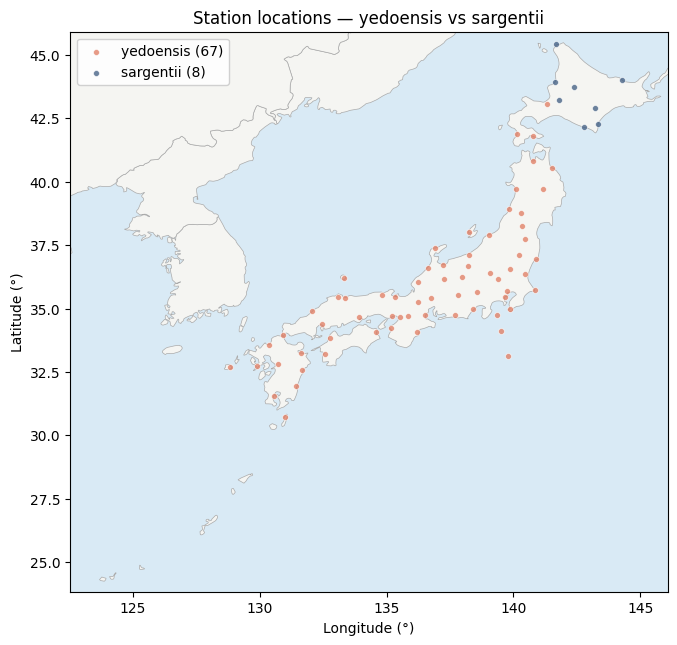

In [12]:
from pysephone.visualize.dataset import _naturalearth_countries, _map_bounds

world = _naturalearth_countries()

# Use the bounding box of the union of both datasets so neither is cropped.
all_lats, all_lons = [], []
for ds in datasets.values():
    bb = ds.bounding_box
    all_lats.extend([bb['min_lat'], bb['max_lat']])
    all_lons.extend([bb['min_lon'], bb['max_lon']])
minx, maxx = min(all_lons) - 0.5, max(all_lons) + 0.5
miny, maxy = min(all_lats) - 0.5, max(all_lats) + 0.5

fig, ax = plt.subplots(figsize=(7, 7 * (maxy - miny) / (maxx - minx)))
if world is not None:
    world.cx[minx:maxx, miny:maxy].plot(
        ax=ax, color='#f5f5f2', edgecolor='#aaaaaa', linewidth=0.5,
    )
for label, ds in datasets.items():
    lats, lons = [], []
    for loc in ds.locations:
        c = ds.get_location_coordinates(loc)
        lats.append(c['lat'])
        lons.append(c['lon'])
    ax.scatter(lons, lats, s=18, alpha=0.75, color=COLORS[label],
               edgecolors='white', linewidths=0.5,
               label=f'{label} ({len(ds.locations)})')

ax.set_facecolor('#d9eaf5')
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_aspect('equal')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Station locations — yedoensis vs sargentii')
ax.legend(framealpha=0.9, loc='best')
plt.tight_layout()
plt.show()

## Notes

* All single-dataset plots (sections 4–8) are direct calls into
  `pysephone.visualize.dataset` — the same recipe transfers to any
  `Observations` instance, not just GMU cherry.
* The two GMU datasets here are aggregated to a 0.5° grid by the registry
  (`aggregate_in_grid(method='median')`), so each "location" is a grid-cell
  median, not a raw station. Pass `do_agg=False` via a custom builder if you
  need station-level data.
* The latitude trend in section 9c uses raw per-sample DOYs, so it mixes
  spatial and temporal variation. For a clean latitude effect, fit on the
  per-location climatological mean DOY instead.